In [60]:
import numpy as np
import struct
from array import array
from os.path  import join

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        


In [61]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

In [62]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train = x_train / np.max(x_train)
x_test = x_test / np.max(x_test)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [63]:
def relu(input):
    return np.maximum(0, input)

In [64]:
def softmax(input, axis=-1):
    exponent = input - np.max(input, axis=axis, keepdims=True)
    numerator = np.exp(exponent)
    denominator = np.sum(numerator, axis=axis, keepdims=True)
    probabilities = numerator / denominator
    return probabilities

In [65]:
class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return relu(result)

class SoftmaxLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return softmax(result)

In [66]:
def initialize_layers():
    rng = np.random.default_rng()

    input_size = x_train.shape[1]

    hidden_layer_size = 64
    hidden_layer_weights = rng.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden_layer_size))
    hidden_layer_biases = np.zeros(shape=(hidden_layer_size,))
    hidden_layer = ReluLayer(hidden_layer_weights, hidden_layer_biases)

    hidden_layer2_size = 64
    hidden_layer2_weights = rng.normal(0, np.sqrt(2.0 / hidden_layer_size), size=(hidden_layer_size, hidden_layer2_size))
    hidden_layer2_biases = np.zeros(shape=(hidden_layer2_size,))
    hidden_layer2 = ReluLayer(hidden_layer2_weights, hidden_layer2_biases)

    output_layer_size = 10
    output_layer_weights = rng.normal(0, np.sqrt(1.0 / hidden_layer2_size), size=(hidden_layer2_size, output_layer_size))
    output_layer_biases = np.zeros(shape=(output_layer_size,))
    output_layer = SoftmaxLayer(output_layer_weights, output_layer_biases)

    return hidden_layer, hidden_layer2, output_layer

In [67]:
hidden_layer, hidden_layer2, output_layer = initialize_layers()

In [68]:
def forward(input):
    hidden_layer_output = hidden_layer.forward(input)
    hidden_layer2_output = hidden_layer2.forward(hidden_layer_output)
    final_output = output_layer.forward(hidden_layer2_output)
    return hidden_layer_output, hidden_layer2_output, final_output

In [69]:
def compute_loss(output, expected_output):
    return -np.log(output[expected_output] + 1e-9)

In [70]:
def backward(input, hidden_layer_output, hidden_layer2_output, final_output, expected_ouput):
    y_true_onehot = np.zeros(10)
    y_true_onehot[expected_ouput] = 1

    dL_dz_output = final_output - y_true_onehot

    dW_output = np.outer(hidden_layer2_output, dL_dz_output)
    db_output = dL_dz_output

    dL_dz_hidden2 = np.dot(output_layer.weights, dL_dz_output) * (hidden_layer2_output > 0).astype(float)

    dW_hidden2 = np.outer(hidden_layer_output, dL_dz_hidden2)
    db_hidden2 = dL_dz_hidden2

    dL_dz_hidden = np.dot(hidden_layer2.weights, dL_dz_hidden2) * (hidden_layer_output > 0).astype(float)

    dW_hidden = np.outer(input, dL_dz_hidden)
    db_hidden = dL_dz_hidden

    return dW_output, db_output, dW_hidden2, db_hidden2, dW_hidden, db_hidden

In [71]:
def update_parameters(dW_output, db_output, dW_hidden2, db_hidden2, dW_hidden, db_hidden, learning_rate=0.01):
    output_layer.weights -= dW_output * learning_rate
    output_layer.biases -= db_output * learning_rate
    hidden_layer2.weights -= dW_hidden2 * learning_rate
    hidden_layer2.biases -= db_hidden2 * learning_rate
    hidden_layer.weights -= dW_hidden * learning_rate
    hidden_layer.biases -= db_hidden * learning_rate

In [72]:
def train(input, expected_output, learning_rate=0.01):
    hidden_layer_output, hidden_layer2_output, final_output = forward(input)
    loss = compute_loss(final_output, expected_output)

    dW_output, db_output, dW_hidden2, db_hidden2, dW_hidden, db_hidden = backward(
        input, hidden_layer_output, hidden_layer2_output, final_output, expected_output
    )

    update_parameters(dW_output, db_output, dW_hidden2, db_hidden2, dW_hidden, db_hidden, learning_rate)

    return loss

In [73]:
def test_accuracy():
    test_size = len(x_test)
    correct_predictions = 0

    for i in range(test_size):
        _, _, final_output = forward(x_test[i])
        predicted_label = np.argmax(final_output)
        if predicted_label == y_test[i]:
            correct_predictions += 1
    
    accuracy = correct_predictions / test_size

    return accuracy


In [74]:
epochs = 20
learning_rate = 0.01

for epoch in range(epochs):
    train_size = len(x_train)
    total_loss = 0
    
    for i in range(train_size):
        loss = train(x_train[i], y_train[i], learning_rate)
        total_loss += loss

    avg_loss = total_loss / train_size

    print(f"Epoch {epoch + 1} finished. Avg. Loss: {avg_loss}")

accuracy = test_accuracy()
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Epoch 1 finished. Avg. Loss: 0.23264492006906617
Epoch 2 finished. Avg. Loss: 0.11984725476592045
Epoch 3 finished. Avg. Loss: 0.09025172866967363
Epoch 4 finished. Avg. Loss: 0.07622775347504279
Epoch 5 finished. Avg. Loss: 0.06831019098654917
Epoch 6 finished. Avg. Loss: 0.0595217831079172
Epoch 7 finished. Avg. Loss: 0.05710051041127383
Epoch 8 finished. Avg. Loss: 0.053687631412501775
Epoch 9 finished. Avg. Loss: 0.04969880340320893
Epoch 10 finished. Avg. Loss: 0.04420105368568609
Epoch 11 finished. Avg. Loss: 0.04380280915997977
Epoch 12 finished. Avg. Loss: 0.03966898545773903
Epoch 13 finished. Avg. Loss: 0.04633961780022196
Epoch 14 finished. Avg. Loss: 0.042385351699829966
Epoch 15 finished. Avg. Loss: 0.04272493799937924
Epoch 16 finished. Avg. Loss: 0.04439822253299462
Epoch 17 finished. Avg. Loss: 0.04082666145123857
Epoch 18 finished. Avg. Loss: 0.03524682296580478
Epoch 19 finished. Avg. Loss: 0.035824804015295565
Epoch 20 finished. Avg. Loss: 0.034852891459292455
Test A

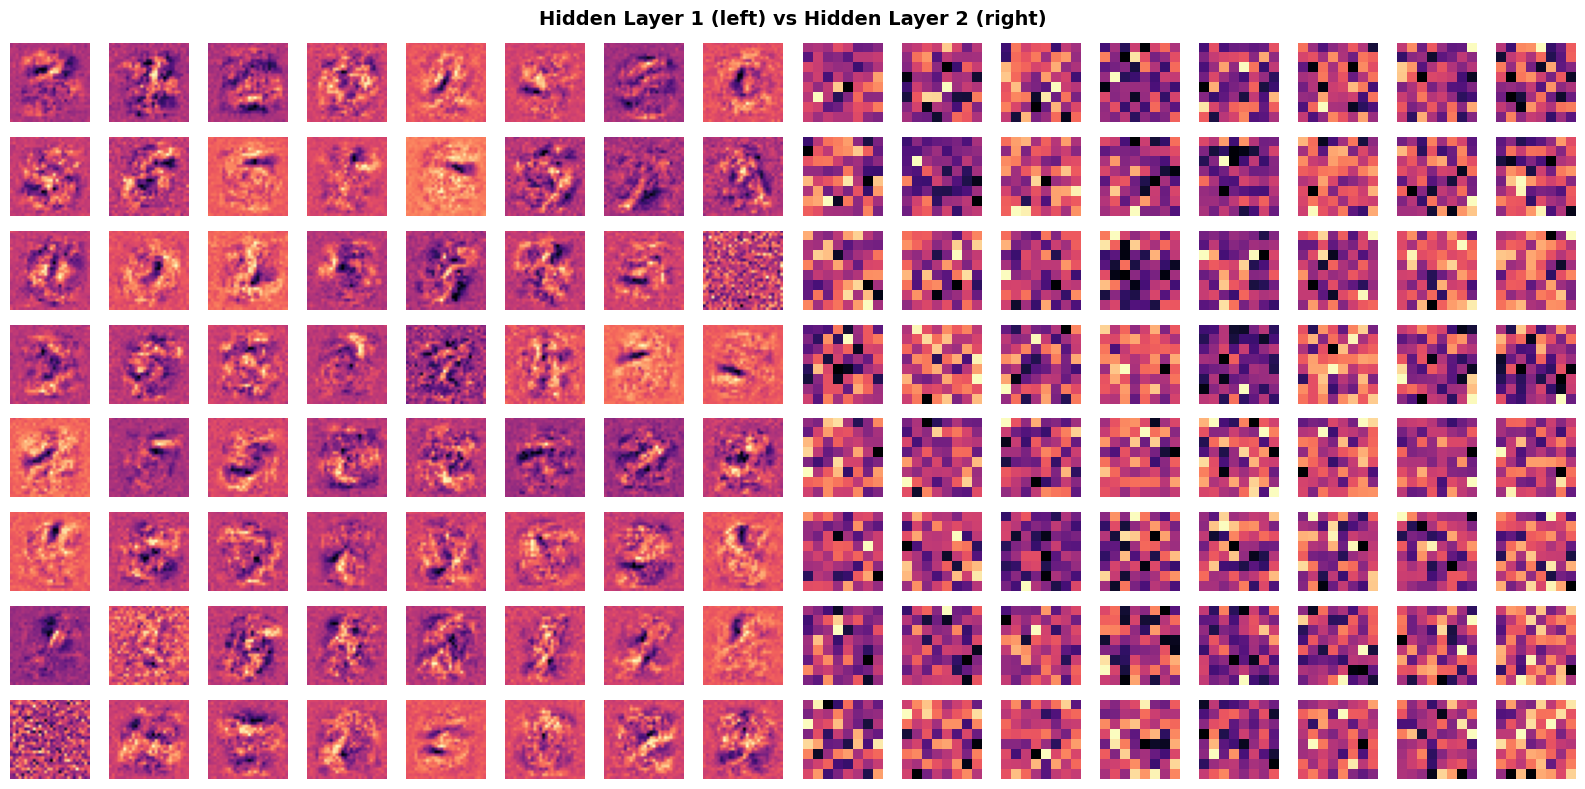

In [75]:
hidden_layer_weights = hidden_layer.weights.T
hidden_layer2_weights = hidden_layer2.weights.T
number_of_neurons = hidden_layer_weights.shape[0]

columns = 8
rows = (number_of_neurons + columns - 1) // columns

fig, axes = plt.subplots(rows, columns * 2, figsize=(16, rows * 1))

for i in range(rows * columns):
    ax = axes[i // columns, (i % columns)]
    if i < number_of_neurons:
        img = hidden_layer_weights[i].reshape(28, 28)
        ax.imshow(img, cmap='magma')
    ax.axis('off')

for i in range(rows * columns):
    ax = axes[i // columns, columns + (i % columns)]
    if i < number_of_neurons:
        img = hidden_layer2_weights[i].reshape(8, 8)
        ax.imshow(img, cmap='magma')
    ax.axis('off')

plt.suptitle('Hidden Layer 1 (left) vs Hidden Layer 2 (right)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

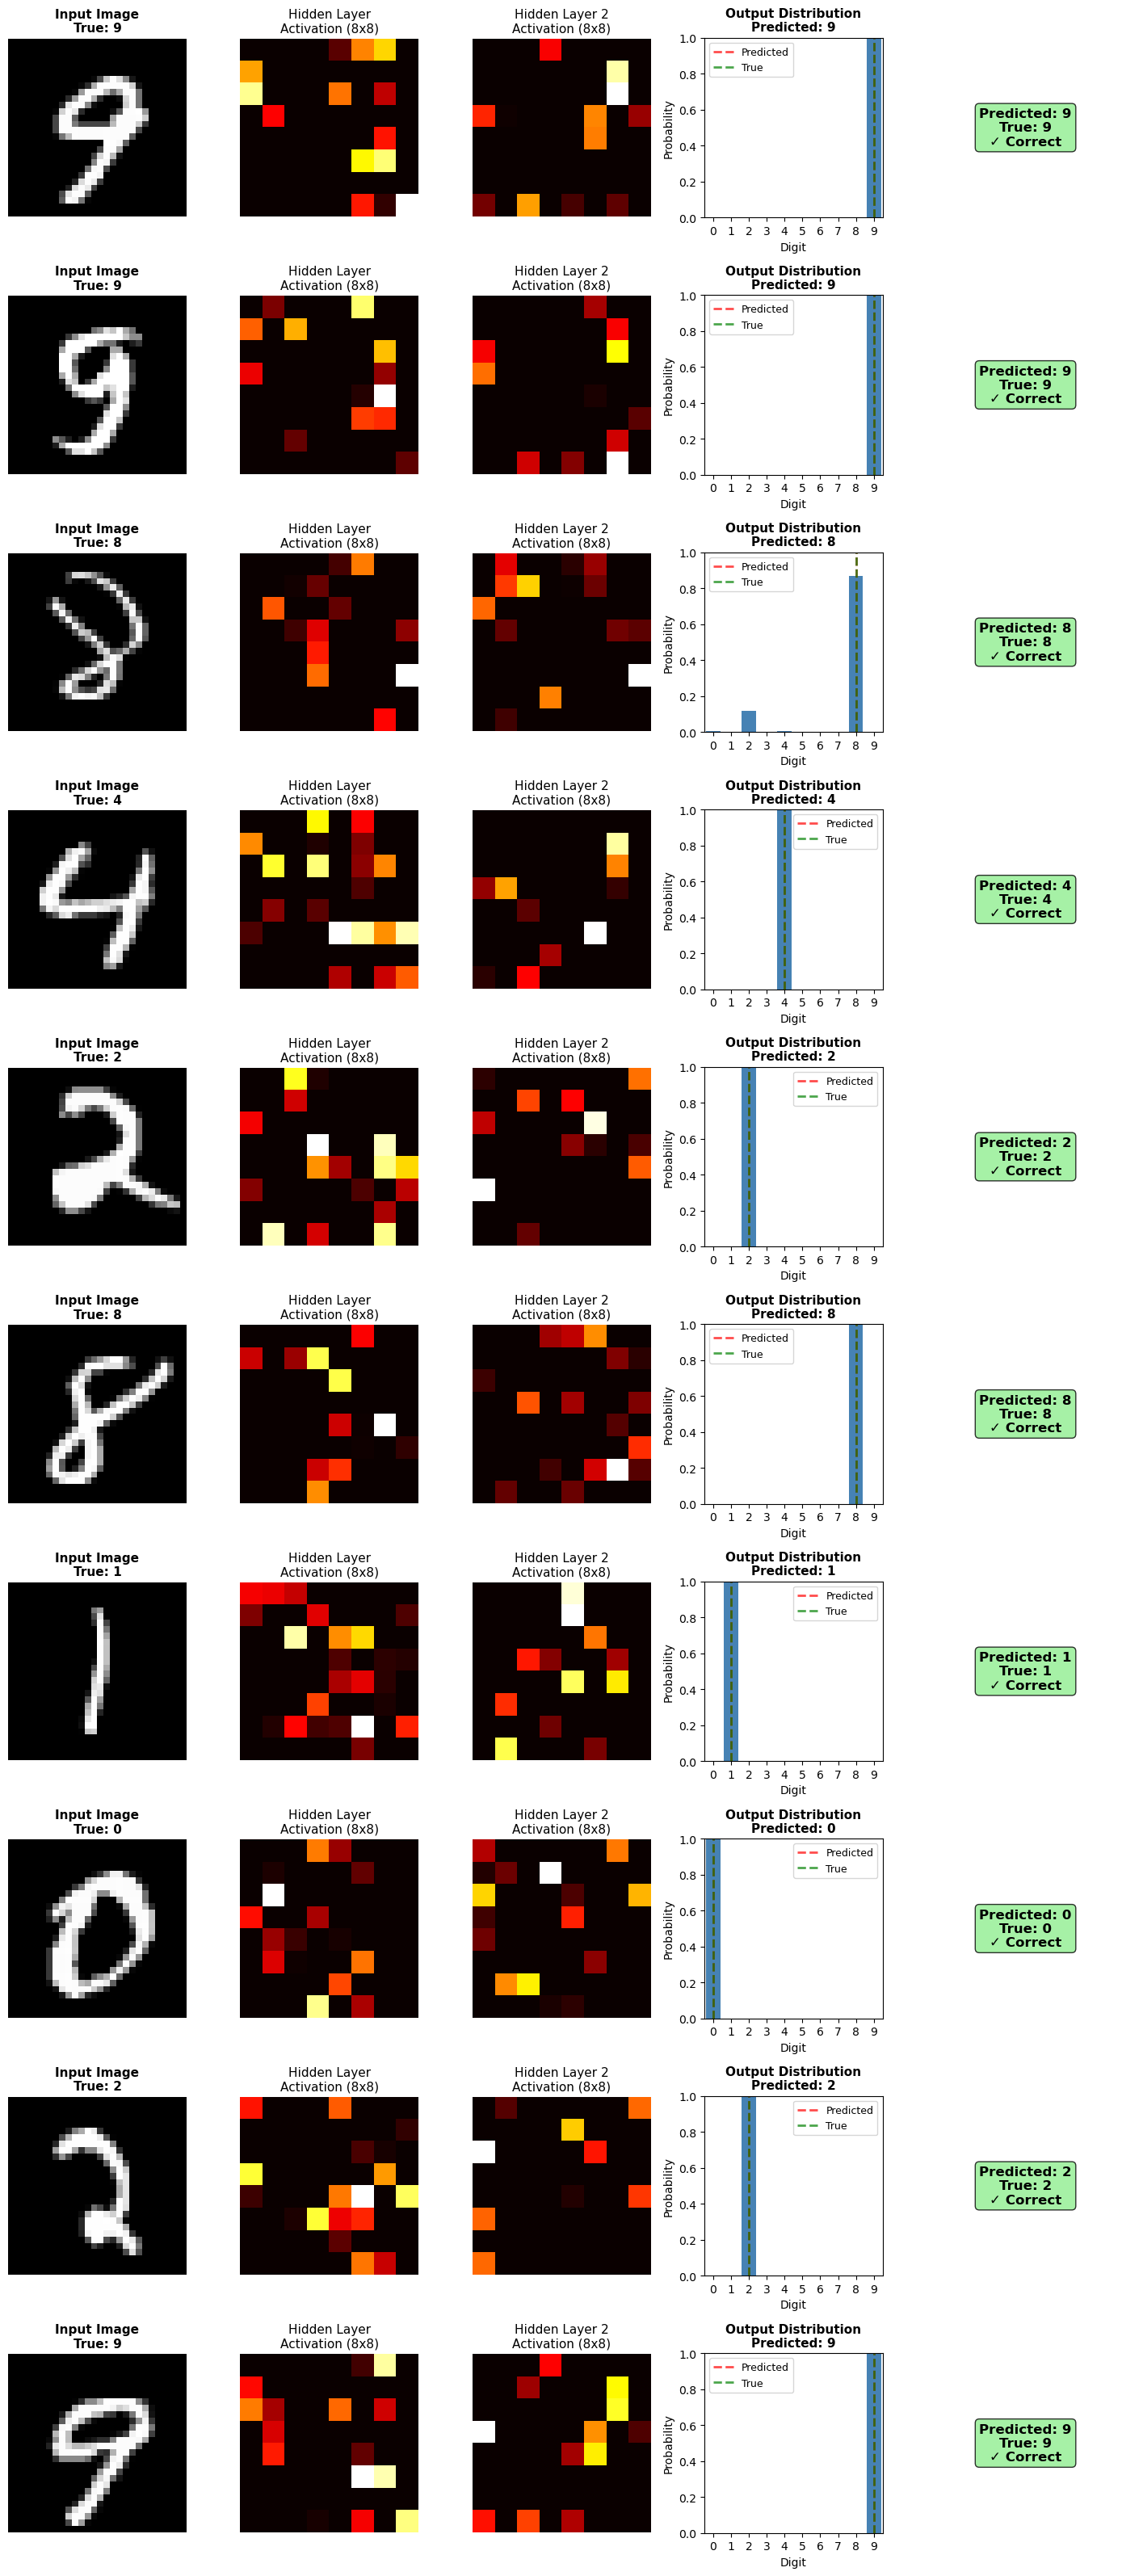

In [90]:
random_indices = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(10, 5, figsize=(14, 32))

for row, idx in enumerate(random_indices):
    input_image = x_test[idx]
    
    hidden_activation, hidden2_activation, final_output = forward(input_image)
    
    predicted_label = np.argmax(final_output)
    true_label = y_test[idx]
    
    ax = axes[row, 0]
    ax.imshow(input_image.reshape(28, 28), cmap='gray')
    ax.set_title(f'Input Image\nTrue: {true_label}', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    ax = axes[row, 1]
    hidden_viz = hidden_activation.reshape(8, 8)
    ax.imshow(hidden_viz, cmap='hot')
    ax.set_title(f'Hidden Layer\nActivation (8x8)', fontsize=11)
    ax.axis('off')

    ax = axes[row, 2]
    hidden_viz = hidden2_activation.reshape(8, 8)
    ax.imshow(hidden_viz, cmap='hot')
    ax.set_title(f'Hidden Layer 2\nActivation (8x8)', fontsize=11)
    ax.axis('off')
    
    ax = axes[row, 3]
    ax.bar(range(10), final_output, color='steelblue')
    ax.set_xlabel('Digit')
    ax.set_ylabel('Probability')
    ax.set_title(f'Output Distribution\nPredicted: {predicted_label}', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, 9.5)
    ax.set_xticks(range(10))
    ax.set_ylim([0, 1])
    ax.axvline(predicted_label, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Predicted')
    ax.axvline(true_label, color='green', linestyle='--', linewidth=2, alpha=0.7, label='True')
    ax.legend(fontsize=9)
    
    ax = axes[row, 4]
    ax.axis('off')
    result_text = f'Predicted: {predicted_label}\nTrue: {true_label}\n'
    if predicted_label == true_label:
        result_text += '✓ Correct'
        ax.text(0.5, 0.5, result_text, fontsize=12, ha='center', va='center', 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), fontweight='bold')
    else:
        result_text += '✗ Incorrect'
        ax.text(0.5, 0.5, result_text, fontsize=12, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8), fontweight='bold')

plt.tight_layout()
plt.show()
